    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [2]:
np.random.seed(42)
torch.manual_seed(42)

N_STOCKS   = 10
N_DAYS     = 252
LOOKBACK   = 21   
HORIZON    = 21   

INPUT_DIM  = LOOKBACK * N_STOCKS   
HIDDEN_DIM = 64
N          = HORIZON               
M          = N_STOCKS

n1    = 0.10  
C     = 1.0    
d     = float(N)  
x_min = 0.0    
x_max = 0.30   
lam   = 1.0    

EPOCHS     = 50
BATCH_SIZE = 16
LR         = 1e-3

In [3]:
# 1. Random Data 
stock_names = [f"S{i+1}" for i in range(N_STOCKS)]
mu    = np.random.uniform(0.001, 0.01, N_STOCKS)
sigma = np.random.uniform(0.01,   0.05,  N_STOCKS)
returns_np  = np.random.normal(mu, sigma, size=(N_DAYS, N_STOCKS))  # (252, 10)

dates       = pd.bdate_range(end="2025-12-31", periods=N_DAYS)
returns_df  = pd.DataFrame(returns_np, index=dates, columns=stock_names)

IS_END_IDX  = N_DAYS // 2   # 126  ── IS/OOS boundary
BT_START    = IS_END_IDX    # backtest starts here

print(f"IS  : {dates[0].date()} → {dates[IS_END_IDX-1].date()}  ({IS_END_IDX} days)")
print(f"BT  : {dates[BT_START].date()} → {dates[-1].date()}  ({N_DAYS - BT_START} days)")


IS  : 2025-01-14 → 2025-07-08  (126 days)
BT  : 2025-07-09 → 2025-12-31  (126 days)


In [4]:
def make_windows(arr, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z      = arr[t - lookback : t].flatten()   # (lookback * m,)
        r_real = arr[t : t + horizon]              # (N, m)
        samples.append((z, r_real))
    return samples

# IS samples  (need lookback history → start from index LOOKBACK)
is_samples    = make_windows(returns_np, LOOKBACK, HORIZON,
                              start=LOOKBACK, end=IS_END_IDX)

# BT samples  (all windows in OOS, step by step)
bt_samples_all = make_windows(returns_np, LOOKBACK, HORIZON,
                               start=BT_START, end=N_DAYS)

# Monthly rebalancing: one window per HORIZON days
rebal_samples = bt_samples_all[::HORIZON]

print(f"\nIS training windows : {len(is_samples)}")
print(f"BT rebal windows    : {len(rebal_samples)}")



IS training windows : 85
BT rebal windows    : 6


In [5]:
from dfl_mdd import (
    PredictionModel,
    build_optimization_layer,
    solve_portfolio,
    compute_cumulative_path,
    compute_realized_path,
    compute_return,
    compute_max_drawdown,
    dfl_loss,
    forward_pass,
    plot_pnl,
)

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/cvxpylayers/torch/cvxpylayer.py:429: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:51.)
  torch_csr = torch.sparse_csr_tensor(



── IS Training ──
  Epoch   1/50  loss = 0.028322
  Epoch   5/50  loss = 0.026803
  Epoch  10/50  loss = 0.029448
  Epoch  15/50  loss = 0.027903
  Epoch  20/50  loss = 0.027903
  Epoch  25/50  loss = 0.028630
  Epoch  30/50  loss = 0.026369
  Epoch  35/50  loss = 0.028310
  Epoch  40/50  loss = 0.026842
  Epoch  45/50  loss = 0.028804
  Epoch  50/50  loss = 0.027969

── Backtest (walk-forward, monthly rebalancing) ──
 Win    R_real       MDD  Top-3 weights
-------------------------------------------------------
   1    0.0155    0.0164  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   2    0.0097    0.0163  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   3    0.0101    0.0212  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   4    0.0053    0.0626  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   5    0.0054    0.0413  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}
   6    0.0025    0.0724  {'S8': 0.3, 'S6': 0.3, 'S2': 0.3}


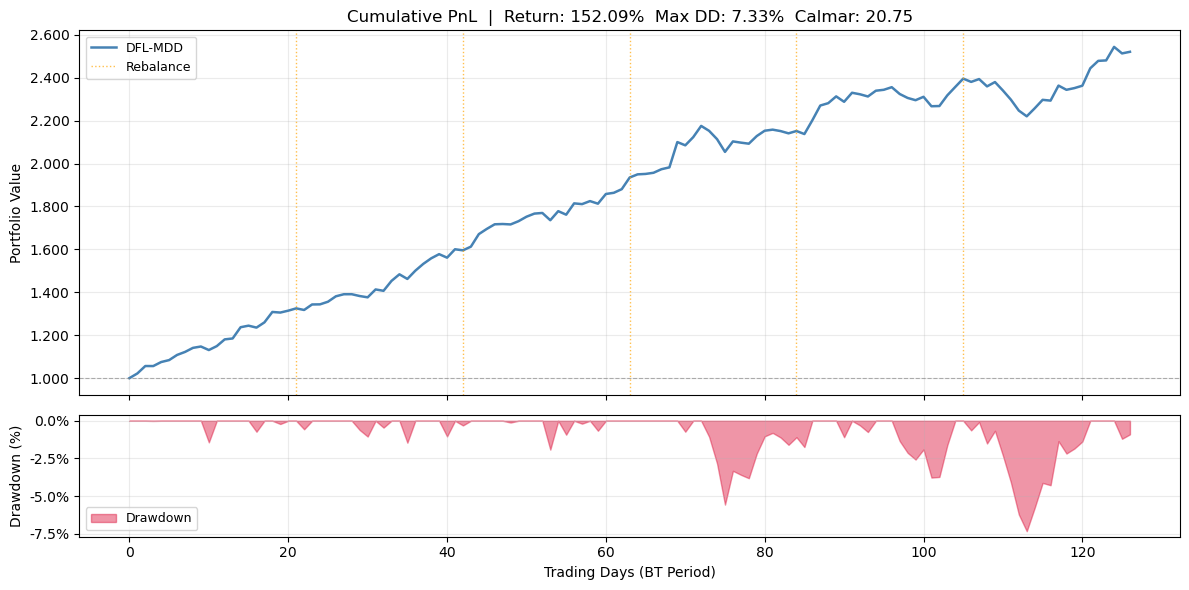


── PnL Summary (DFL-MDD) ──
  Final Value  : 2.5209
  Total Return : 152.0902%
  Max Drawdown : 7.3290%
  Calmar Ratio : 20.7519


In [6]:

pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
opt_layer  = build_optimization_layer(N, M)
optimizer  = optim.Adam(pred_model.parameters(), lr=LR)

def to_tensors(samples):
    zs      = torch.tensor(np.array([s[0] for s in samples]), dtype=torch.float32)
    r_reals = torch.tensor(np.array([s[1] for s in samples]), dtype=torch.float32)
    return zs, r_reals   # (B, input_dim),  (B, N, m)

zs_is, rs_is = to_tensors(is_samples)


print("\n── IS Training ──")
pred_model.train()

for epoch in range(EPOCHS):
    perm   = torch.randperm(len(is_samples))
    ep_loss = []

    for i in range(0, len(is_samples), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        z_b = zs_is[idx]
        r_b = rs_is[idx]

        optimizer.zero_grad()
        result = forward_pass(z_b, r_b, pred_model, opt_layer,
                              n1, C, d, x_min, x_max, lam)
        result["loss"].backward()
        optimizer.step()
        ep_loss.append(result["loss"].item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")


pred_model.eval()
bt_results = []

print("\n── Backtest (walk-forward, monthly rebalancing) ──")
print(f"{'Win':>4}  {'R_real':>8}  {'MDD':>8}  {'Top-3 weights'}")
print("-" * 55)

for i, (z_np, r_np) in enumerate(rebal_samples):
    z      = torch.tensor(z_np[None],  dtype=torch.float32)   
    r_real = torch.tensor(r_np[None],  dtype=torch.float32)   

    with torch.no_grad():
        r_hat = pred_model(z)                       

    y_hat  = compute_cumulative_path(r_hat)          
    x_star = solve_portfolio(y_hat.detach(), opt_layer, n1, C, x_min, x_max)  

    y_real = compute_cumulative_path(r_real)
    w_real = compute_realized_path(x_star, y_real)   
    R_real = compute_return(w_real, d, C)
    M_real = compute_max_drawdown(w_real)

    w = x_star[0].numpy()
    top3 = {stock_names[j]: round(w[j], 3)
            for j in np.argsort(w)[-3:][::-1]}

    bt_results.append({
        "window": i + 1,
        "weights": w,
        "w_real":  w_real[0].detach().numpy(),   
        "R_real":  R_real[0].item(),
        "M_real":  M_real[0].item(),
    })
    print(f"  {i+1:2d}  {R_real[0].item():8.4f}  {M_real[0].item():8.4f}  {top3}")

plot_pnl(bt_results, horizon=HORIZON, label = 'DFL-MDD')



── PTO-MDD Training (MSE) ──
  Epoch   1/50  mse = 0.006112
  Epoch   5/50  mse = 0.001212
  Epoch  10/50  mse = 0.000761
  Epoch  15/50  mse = 0.000743
  Epoch  20/50  mse = 0.000726
  Epoch  25/50  mse = 0.000719
  Epoch  30/50  mse = 0.000700
  Epoch  35/50  mse = 0.000683
  Epoch  40/50  mse = 0.000667
  Epoch  45/50  mse = 0.000654
  Epoch  50/50  mse = 0.000638

── PTO-MVO Training (MSE) ──
  Epoch   1/50  mse = 0.006547
  Epoch   5/50  mse = 0.001410
  Epoch  10/50  mse = 0.000770
  Epoch  15/50  mse = 0.000744
  Epoch  20/50  mse = 0.000731
  Epoch  25/50  mse = 0.000727
  Epoch  30/50  mse = 0.000720
  Epoch  35/50  mse = 0.000701
  Epoch  40/50  mse = 0.000698
  Epoch  45/50  mse = 0.000678
  Epoch  50/50  mse = 0.000670

── Backtest : PTO-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-------------------------------------------------------
   1    0.0103   1.5969%  {'S8': 0.3, 'S3': 0.3, 'S9': 0.3}
   2    0.0136   1.9866%  {'S8': 0.3, 'S3': 0.3, 'S2': 0.3}
   3    0.0091  

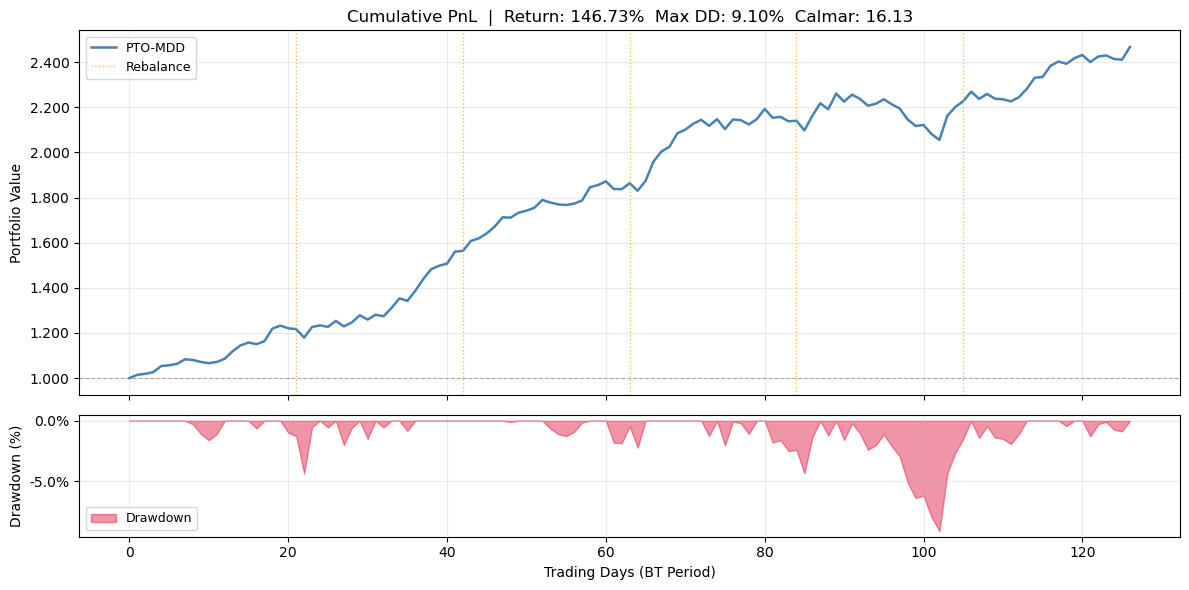


── PnL Summary (PTO-MDD) ──
  Final Value  : 2.4673
  Total Return : 146.7317%
  Max Drawdown : 9.0967%
  Calmar Ratio : 16.1303


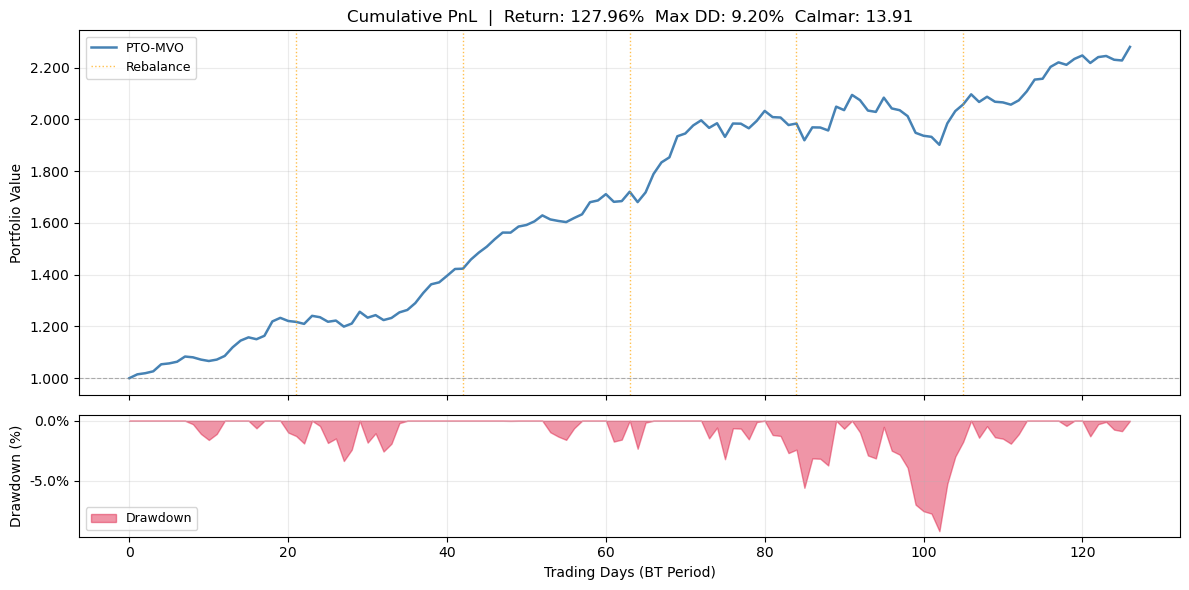


── PnL Summary (PTO-MVO) ──
  Final Value  : 2.2796
  Total Return : 127.9619%
  Max Drawdown : 9.2017%
  Calmar Ratio : 13.9064


In [7]:
from dfl_mdd  import PredictionModel, forward_pass, plot_pnl
from pto_mdd  import train_pto_mdd,  backtest_pto_mdd
from pto_mvo  import train_pto_mvo,  backtest_pto_mvo 

# 각 모델은 독립적인 PredictionModel 인스턴스 사용 (가중치 공유 X)
model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mdd(model_pto_mdd, is_samples, EPOCHS, BATCH_SIZE, LR)
train_pto_mvo(model_pto_mvo, is_samples, EPOCHS, BATCH_SIZE, LR)

bt_pto_mdd = backtest_pto_mdd(
    pred_model   = model_pto_mdd,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    n1           = n1,
    x_min        = x_min,
    x_max        = x_max,
    stock_names  = stock_names,
)

bt_pto_mvo = backtest_pto_mvo(
    pred_model   = model_pto_mvo,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    lam_mvo      = 1.0,
    x_min        = x_min,
    x_max        = x_max,
    stock_names  = stock_names,
)

plot_pnl(bt_pto_mdd, horizon=HORIZON, label = 'PTO-MDD')
plot_pnl(bt_pto_mvo, horizon=HORIZON, label = 'PTO-MVO')
